# Restaurant Recommendation Engine 

### Problem Statement 
The objective of this project is to build a recommendation engine to predict what restaurants
customers are most likely to order from, given the customer location, restaurant information, and the
customer order history.
 



## 1. Imports & Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from math import radians, sin, cos, sqrt, atan2
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Libraries loaded.')
print('Model: HistGradientBoostingClassifier (histogram-based GBM — LightGBM-style)')

Libraries loaded.
Model: HistGradientBoostingClassifier (histogram-based GBM — LightGBM-style)


##  2. Load Data

In [6]:
orders      = pd.read_csv('Train/orders.csv', low_memory=False)
train_locs  = pd.read_csv('Train/train_locations.csv')
train_cust  = pd.read_csv('Train/train_customers.csv')
vendors     = pd.read_csv('Train/vendors.csv')
test_locs   = pd.read_csv('Test/test_locations.csv')
test_cust   = pd.read_csv('Test/test_customers.csv')

# Fix numeric columns
for col in ['grand_total','item_count','deliverydistance',
            'vendor_rating','driver_rating','is_favorite','is_rated']:
    orders[col] = pd.to_numeric(orders[col], errors='coerce')

orders['created_at'] = pd.to_datetime(orders['created_at'], errors='coerce')

print('Dataset shapes:')
print(f'  Orders:          {orders.shape}')
print(f'  Train locations: {train_locs.shape}')
print(f'  Vendors:         {vendors.shape}')
print(f'  Test locations:  {test_locs.shape}')
print(f'\nDate range: {orders["created_at"].min().date()} → {orders["created_at"].max().date()}')

Dataset shapes:
  Orders:          (135303, 26)
  Train locations: (59503, 5)
  Vendors:         (100, 59)
  Test locations:  (16720, 5)

Date range: 2020-01-01 → 2024-12-31


##  3. EDA

In [10]:
print('KEY STATISTICS \n')
print(f'Unique customers in orders: {orders["customer_id"].nunique():,}')
print(f'Unique vendors: {orders["vendor_id"].nunique():,}')
print(f'Unique CID x LOC x VEN combos: {orders["CID X LOC_NUM X VENDOR"].nunique():,}')
print(f'Avg order value: ${orders["grand_total"].mean():.2f}')
print(f'Avg delivery distance: {orders["deliverydistance"].mean():.2f} km')
print(f'Open vendors: {vendors["is_open"].sum()} / {len(vendors)}')

opc = orders.groupby('customer_id').size()
print(f'\nOrders per customer — mean: {opc.mean():.1f}, median: {opc.median():.0f}, max: {opc.max()}')
print(f'Cold-start (1 order): {(opc==1).sum():,} ({(opc==1).mean()*100:.1f}%)')

KEY STATISTICS 

Unique customers in orders: 27,445
Unique vendors: 100
Unique CID x LOC x VEN combos: 80,142
Avg order value: $15.37
Avg delivery distance: 4.10 km
Open vendors: 85 / 100

Orders per customer — mean: 4.9, median: 2, max: 262
Cold-start (1 order): 9,919 (36.1%)


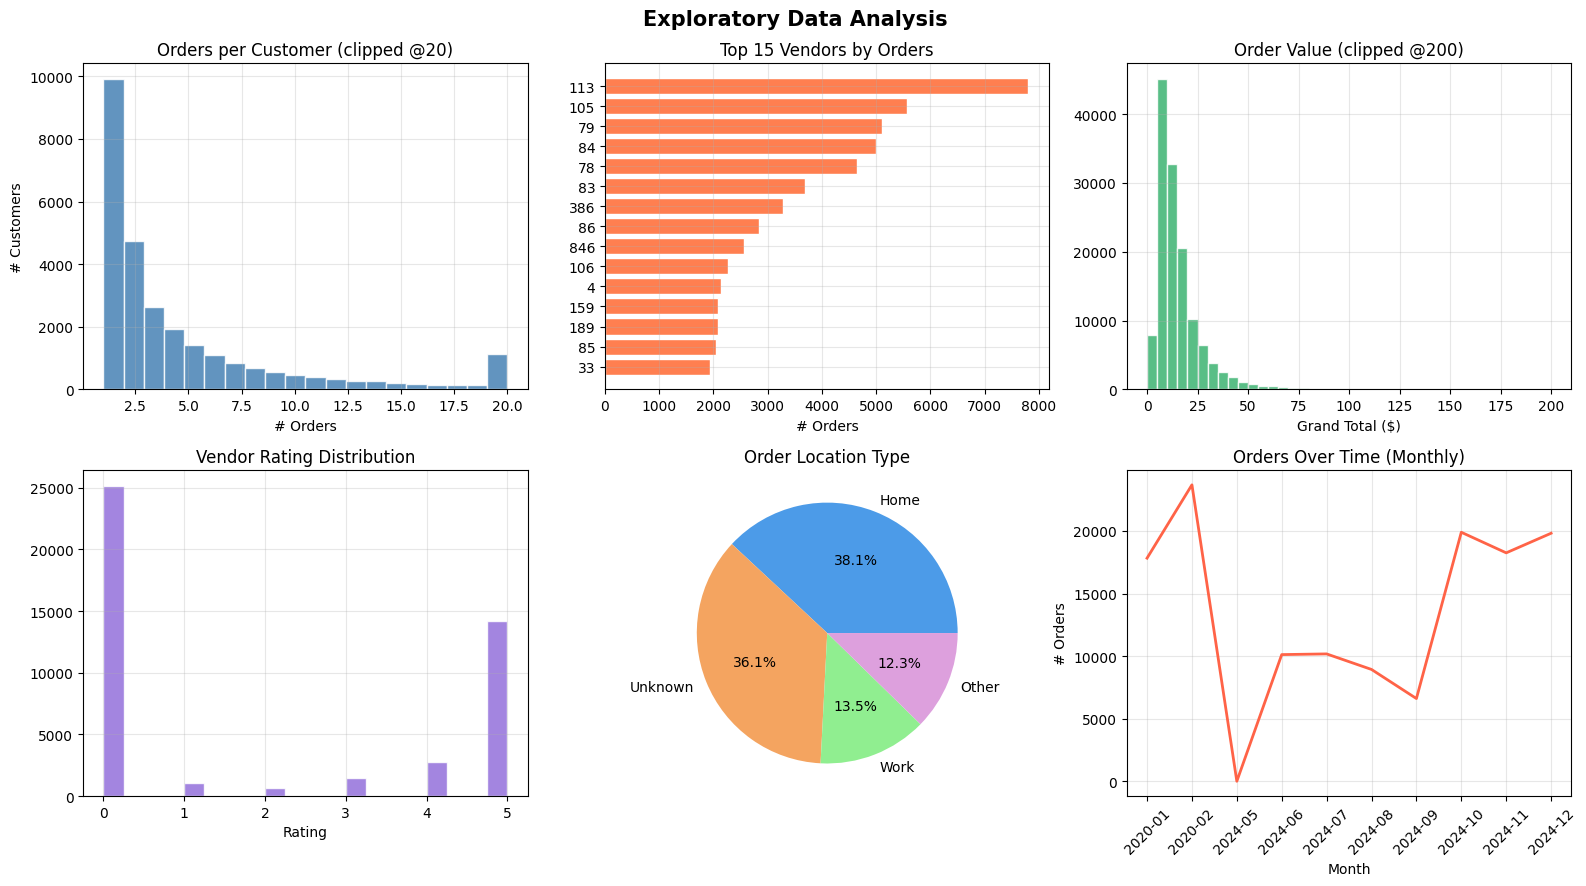

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold')

# Orders per customer
ax = axes[0,0]
ax.hist(opc.clip(upper=20), bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Orders per Customer (clipped @20)')
ax.set_xlabel('# Orders'); ax.set_ylabel('# Customers')

# Top 15 vendors
ax = axes[0,1]
top15 = orders.groupby('vendor_id').size().sort_values(ascending=False).head(15)
ax.barh(top15.index.astype(str), top15.values, color='coral', edgecolor='white')
ax.set_title('Top 15 Vendors by Orders')
ax.set_xlabel('# Orders'); ax.invert_yaxis()

# Grand total
ax = axes[0,2]
ax.hist(orders['grand_total'].dropna().clip(upper=200), bins=40,
        color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_title('Order Value (clipped @200)')
ax.set_xlabel('Grand Total ($)')

# Vendor rating
ax = axes[1,0]
ax.hist(orders['vendor_rating'].dropna(), bins=20,
        color='mediumpurple', edgecolor='white', alpha=0.85)
ax.set_title('Vendor Rating Distribution')
ax.set_xlabel('Rating')

# Location type
ax = axes[1,1]
lc = orders['LOCATION_TYPE'].value_counts(dropna=False)
labels = [str(l) if str(l) != 'nan' else 'Unknown' for l in lc.index]
ax.pie(lc.values, labels=labels, autopct='%1.1f%%',
       colors=['#4c9be8','#f4a460','#90ee90','#dda0dd'])
ax.set_title('Order Location Type')

# Orders over time
ax = axes[1,2]
monthly = orders.groupby(orders['created_at'].dt.to_period('M')).size()
ax.plot(monthly.index.astype(str), monthly.values, color='tomato', linewidth=2)
ax.set_title('Orders Over Time (Monthly)')
ax.set_xlabel('Month'); ax.set_ylabel('# Orders')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Temporal Train / Validation Split

**Why temporal split?**
We use a temporal split to mimic real-world conditions—training on past data and predicting future behavior—while preventing data leakage from future orders into features like customer history.

This ensures `cv_order_count` and all interaction features are built from **past data only** — no leakage.

In [13]:
CUTOFF = orders['created_at'].quantile(0.8)
print(f'Temporal split cutoff: {CUTOFF.date()}')

train_orders = orders[orders['created_at'] <= CUTOFF].copy()
val_orders   = orders[orders['created_at'] >  CUTOFF].copy()

print(f'\nTrain orders: {len(train_orders):,} ({len(train_orders)/len(orders)*100:.0f}%)')
print(f'Val orders:   {len(val_orders):,} ({len(val_orders)/len(orders)*100:.0f}%)')
print(f'\nTrain unique customers: {train_orders["customer_id"].nunique():,}')
print(f'Val unique customers:   {val_orders["customer_id"].nunique():,}')

warm_users = set(train_orders['customer_id']) & set(val_orders['customer_id'])
cold_users = set(val_orders['customer_id']) - set(train_orders['customer_id'])
print(f'\nWarm users (in both):  {len(warm_users):,}')
print(f'Cold-start users:      {len(cold_users):,}')

Temporal split cutoff: 2024-11-18

Train orders: 108,242 (80%)
Val orders:   27,061 (20%)

Train unique customers: 25,341
Val unique customers:   10,719

Warm users (in both):  8,615
Cold-start users:      2,104


## 5. Feature Engineering

We created features in 4 groups:

### i) Geospatial Features
- Haversine distance between customer and vendor  
- `distance_km`, `within_serving`, `dist_bucket`  
- Nearby vendors are more likely to be chosen  

---

### ii) Vendor Attributes
- Rating, delivery charge, prep time, category, rank, is_open  
- Describes vendor quality and service  

---

### iii) Vendor Popularity
- Total orders, average spend, average rating, favorite rate  
- Indicates overall demand for a vendor  

---

### iv) Customer–Vendor Interaction
- `cv_order_count`, `cv_is_repeat`, `cv_avg_rating`, `cv_is_fav`  
- Captures past behavior (strongest signal)  

In [14]:
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two GPS points."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

print('Haversine defined.')

Haversine defined.


In [17]:
#Vendor base features 
vf = vendors[['id','latitude','longitude','delivery_charge','serving_distance',
              'is_open','prepration_time','commission','discount_percentage',
              'vendor_rating','rank','vendor_category_id']].copy()
vf.columns = ['vendor_id'] + [f'v_{c}' for c in vf.columns[1:]]
vf['v_vendor_rating'] = pd.to_numeric(vf['v_vendor_rating'], errors='coerce')
vf['v_rank']          = pd.to_numeric(vf['v_rank'],          errors='coerce')
vf = vf.fillna(vf.median(numeric_only=True))

#Vendor popularity from Train orders 
order_stats = train_orders.groupby('vendor_id').agg(
    total_orders = ('order_id','count'),
    avg_grand_total = ('grand_total','mean'),
    avg_item_count = ('item_count','mean'),
    avg_delivery_dist = ('deliverydistance','mean'),
    avg_vendor_rating = ('vendor_rating','mean'),
    avg_driver_rating = ('driver_rating','mean'),
    fav_rate = ('is_favorite','mean'),
    rated_rate = ('is_rated','mean'),
).reset_index()

#Customer history — from Train orders 
cust_stats = train_orders.groupby('customer_id').agg(
    cust_total_orders = ('order_id','count'),
    cust_unique_vendors = ('vendor_id','nunique'),
    cust_avg_spend = ('grand_total','mean'),
    cust_avg_rating = ('vendor_rating','mean'),
).reset_index()

#Customer x Vendor interactions from TRAIN orders
#Had Encountered error here previoulsy
cust_vendor = train_orders.groupby(['customer_id','vendor_id']).agg(
    cv_order_count = ('order_id','count'),
    cv_avg_rating  = ('vendor_rating','mean'),
    cv_is_fav      = ('is_favorite','max'),
).reset_index()

print('All features built from training period only — no leakage.')
print(f'cv interactions: {len(cust_vendor):,} customer vendor pairs')

All features built from training period only — no leakage.
cv interactions: 60,973 customer vendor pairs


In [18]:
def build_features(df, location_df):
    """Merge all features onto a dataframe with customer_id, LOCATION_NUMBER, vendor_id."""
    df = df.merge(
        location_df.rename(columns={'location_number':'LOCATION_NUMBER'}),
        on=['customer_id','LOCATION_NUMBER'], how='left')
    df = df.merge(vf, on='vendor_id', how='left')
    df = df.merge(order_stats, on='vendor_id', how='left')
    df = df.merge(cust_stats, on='customer_id', how='left')
    df = df.merge(cust_vendor, on=['customer_id','vendor_id'], how='left')

    # Haversine distance(Calc Distance)
    df['distance_km'] = df.apply(
        lambda r: haversine(r['latitude'], r['longitude'], r['v_latitude'], r['v_longitude'])
        if pd.notna(r['latitude']) and pd.notna(r['v_latitude']) else np.nan, axis=1)

    df['within_serving'] = (df['distance_km'] <= df['v_serving_distance']).astype(int)

    # Fill cold-start interaction features with 0
    for col in ['cv_order_count','cv_avg_rating','cv_is_fav']:
        df[col] = df[col].fillna(0)
    df['cv_is_repeat'] = (df['cv_order_count'] > 0).astype(int)

    df['loc_type_enc'] = df['location_type'].map({'Home':0,'Work':1}).fillna(-1)

    # Distance bucket feature
    df['dist_bucket'] = pd.cut(df['distance_km'],
                                bins=[0,1,3,5,10,999],
                                labels=[0,1,2,3,4]).astype(float)
    return df

print('Feature builder function defined.')

Feature builder function defined.


## 6. Building Training Dataset

In [19]:
block 9 - Building Training Dataset
vendor_ids = vendors['id'].tolist()

# Positives: unique combos in train_orders
positives = train_orders[['customer_id','LOCATION_NUMBER','vendor_id']].drop_duplicates()
positives['target'] = 1
print(f'Positives: {len(positives):,}')

# Negatives: random combos NOT in train_orders
pos_set = set(zip(positives['customer_id'], positives['LOCATION_NUMBER'], positives['vendor_id']))
train_pairs = train_locs[['customer_id','location_number']].drop_duplicates()

np.random.seed(42)
neg_rows = []
sample_pairs = train_pairs.sample(min(len(train_pairs), 30000), random_state=42)

for _, row in sample_pairs.iterrows():
    cid, loc = row['customer_id'], row['location_number']
    for vid in np.random.choice(vendor_ids, size=5, replace=False):
        if (cid, loc, vid) not in pos_set:
            neg_rows.append({'customer_id':cid, 'LOCATION_NUMBER':loc,
                             'vendor_id':vid, 'target':0})

negatives = pd.DataFrame(neg_rows)
print(f'Negatives: {len(negatives):,}')

train_df = pd.concat([positives, negatives], ignore_index=True)
print(f'Total training rows: {len(train_df):,}')
print(f'Class balance — positives: {train_df["target"].mean()*100:.1f}%')

Positives: 68,059
Negatives: 148,362
Total training rows: 216,421
Class balance — positives: 31.4%


In [20]:
print('Building train features...')
train_df = build_features(train_df, train_locs)
print(f'Train feature matrix: {train_df.shape}')

Building train features...
Train feature matrix: (216421, 38)


## 7. Building Validation Dataset

Validation positives = orders that happened **after** the cutoff.
Validation negatives = random vendor combos for those customers that they did NOT order from in the val period.

This simulates the real prediction scenario honestly.

In [23]:
# Positives from val period
val_pos = val_orders[['customer_id','LOCATION_NUMBER','vendor_id']].drop_duplicates()
val_pos['target'] = 1

# Negatives for val: combos NOT in val_orders
val_pos_set = set(zip(val_pos['customer_id'], val_pos['LOCATION_NUMBER'], val_pos['vendor_id']))
val_pairs = train_locs[train_locs['customer_id'].isin(val_orders['customer_id'].unique())][['customer_id','location_number']].drop_duplicates()

val_neg_rows = []
sample_val = val_pairs.sample(min(len(val_pairs), 10000), random_state=42)
for _, row in sample_val.iterrows():
    cid, loc = row['customer_id'], row['location_number']
    for vid in np.random.choice(vendor_ids, size=5, replace=False):
        if (cid, loc, vid) not in val_pos_set:
            val_neg_rows.append({'customer_id':cid, 'LOCATION_NUMBER':loc,
                                 'vendor_id':vid, 'target':0})

val_neg = pd.DataFrame(val_neg_rows)
val_df = pd.concat([val_pos, val_neg], ignore_index=True)

print(f'Val positives:{len(val_pos):,}')
print(f'Val negatives:{len(val_neg):,}')
print(f'Val total:{len(val_df):,}')

Val positives:19,125
Val negatives:49,577
Val total:68,702


In [24]:
print('Building val features...')
val_df = build_features(val_df, train_locs)
print(f'Val feature matrix: {val_df.shape}')

Building val features...
Val feature matrix: (68702, 38)


##  8. Model Training — HistGradientBoostingClassifier

**Why HistGradientBoostingClassifier?**
- Histogram-based algorithm identical in principle to LightGBM
- Much faster than sklearn's standard GBM on large datasets
- Built-in early stopping via validation fraction

In [35]:
FEATURE_COLS = [
    # Geospatial
    'distance_km', 'within_serving', 'dist_bucket',
    # Vendor attributes
    'v_delivery_charge', 'v_serving_distance', 'v_is_open',
    'v_prepration_time', 'v_commission', 'v_discount_percentage',
    'v_vendor_rating', 'v_rank', 'v_vendor_category_id',
    # Vendor popularity (from train period only)
    'total_orders', 'avg_grand_total', 'avg_item_count',
    'avg_delivery_dist', 'avg_vendor_rating', 'avg_driver_rating',
    'fav_rate', 'rated_rate',
    # Customer history (from train period only)
    'cust_total_orders', 'cust_unique_vendors', 'cust_avg_spend', 'cust_avg_rating',
    # Customer x Vendor interactions (from train period only — no leakage)
    'cv_order_count', 'cv_avg_rating', 'cv_is_fav', 'cv_is_repeat',
    # Location context
    'loc_type_enc',
]

X_train = train_df[FEATURE_COLS]
y_train = train_df['target']
X_val   = val_df[FEATURE_COLS]
y_val   = val_df['target']

print(f'Training on {len(X_train):,} samples | {len(FEATURE_COLS)} features')
print(f'Validating on {len(X_val):,} samples')

Training on 216,421 samples | 29 features
Validating on 68,702 samples


In [26]:
model = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=30,
    l2_regularization=0.1,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

model.fit(X_train, y_train)
print(f'Training complete. Iterations used: {model.n_iter_}')

Training complete. Iterations used: 407


##  9. Honest Evaluation on Validation Set

In [29]:
y_val_prob  = model.predict_proba(X_val)[:, 1]
y_train_prob = model.predict_proba(X_train)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
val_auc = roc_auc_score(y_val,y_val_prob)
val_ap = average_precision_score(y_val, y_val_prob)

print('----EVALUATION RESULTS---- \n')
print(f'  Train AUC-ROC:        {train_auc:.4f}')
print(f'  Validation AUC-ROC:   {val_auc:.4f}   <- honest metric')
print(f'  Validation Avg Prec:  {val_ap:.4f}')
print('-' * 45)

gap = train_auc - val_auc
if gap < 0.05:
    print(f'  Train-Val gap: {gap:.4f} — good generalisation')
elif gap < 0.15:
    print(f'  Train-Val gap: {gap:.4f} — mild overfitting')
else:
    print(f'  Train-Val gap: {gap:.4f} — significant overfitting')

----EVALUATION RESULTS---- 

  Train AUC-ROC:        0.9988
  Validation AUC-ROC:   0.7480   <- honest metric
  Validation Avg Prec:  0.6701
---------------------------------------------
  Train-Val gap: 0.2509 — significant overfitting


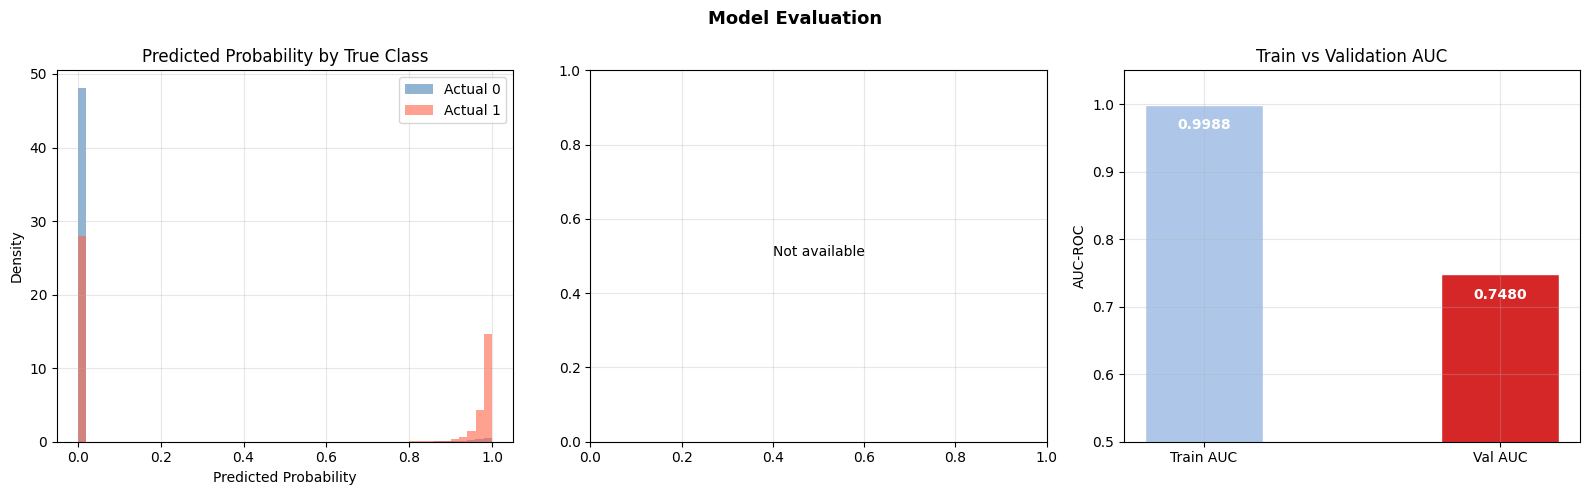

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Evaluation', fontsize=13, fontweight='bold')

# 1. Score distribution by class
ax = axes[0]
ax.hist(y_val_prob[y_val==0], bins=50, alpha=0.6, color='steelblue', label='Actual 0', density=True)
ax.hist(y_val_prob[y_val==1], bins=50, alpha=0.6, color='tomato',    label='Actual 1', density=True)
ax.set_title('Predicted Probability by True Class')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.legend()

# 2. Feature importances (permutation proxy via gain)
ax = axes[1]
try:
    fi = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
    colors = ['#d62728' if 'cv_' in f else '#1f77b4' for f in fi.index]
    ax.barh(fi.index, fi.values, color=colors)
    ax.set_title('Feature Importances\n(red = interaction features)')
    ax.set_xlabel('Importance')
except:
    ax.text(0.5, 0.5, 'Not available', ha='center')

# 3. AUC comparison — train vs val
ax = axes[2]
bars = ax.bar(['Train AUC', 'Val AUC'], [train_auc, val_auc],
               color=['#aec7e8', '#d62728'], edgecolor='white', width=0.4)
for bar, val in zip(bars, [train_auc, val_auc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
            f'{val:.4f}', ha='center', va='top', color='white', fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.set_title('Train vs Validation AUC')
ax.set_ylabel('AUC-ROC')

plt.tight_layout()
plt.show()

## 10. Generate Test Predictions

For each test `customer × location`, score all 100 vendors.

**Prediction strategy:**
- Predict **1** if probability ≥ 0.5, **OR**
- Top 10 vendors per customer-location (cold-start fallback — ensures every user gets recommendations)

In [31]:
# Build all test CID x LOC x VENDOR combos
test_pairs = test_locs[['customer_id','location_number']].drop_duplicates()
test_rows = []
for _, row in test_pairs.iterrows():
    for vid in vendor_ids:
        test_rows.append({'customer_id': row['customer_id'],
                          'LOCATION_NUMBER': row['location_number'],
                          'vendor_id': vid})

test_df = pd.DataFrame(test_rows)
print(f'Total test combos: {len(test_df):,}')

# Build features (same pipeline, using full orders for cust/vendor stats now)
print('Building test features...')
test_df = build_features(test_df, test_locs)
print('Done.')

Total test combos: 1,672,000
Building test features...
Done.


In [32]:
X_test = test_df[FEATURE_COLS]
test_df['prob'] = model.predict_proba(X_test)[:, 1]

# Build submission key
test_df['CID X LOC_NUM X VENDOR'] = (
    test_df['customer_id'].astype(str) + ' X ' +
    test_df['LOCATION_NUMBER'].astype(str) + ' X ' +
    test_df['vendor_id'].astype(str)
)

# Rank-based prediction — explicit ranking strategy
test_df['rank_in_group'] = (
    test_df.groupby(['customer_id','LOCATION_NUMBER'])['prob']
           .rank(method='first', ascending=False)
)

# target = 1 if high prob OR top-10 (cold-start coverage)
test_df['target'] = ((test_df['prob'] >= 0.5) | (test_df['rank_in_group'] <= 10)).astype(int)

n_ones = int(test_df['target'].sum())
n_total = len(test_df)
print(f'Total rows: {n_total:,}')
print(f'Predicted 1s: {n_ones:,} ({n_ones/n_total*100:.2f}%)')
print(f'Predicted 0s: {n_total-n_ones:,}')

Total rows: 1,672,000
Predicted 1s: 167,200 (10.00%)
Predicted 0s: 1,504,800


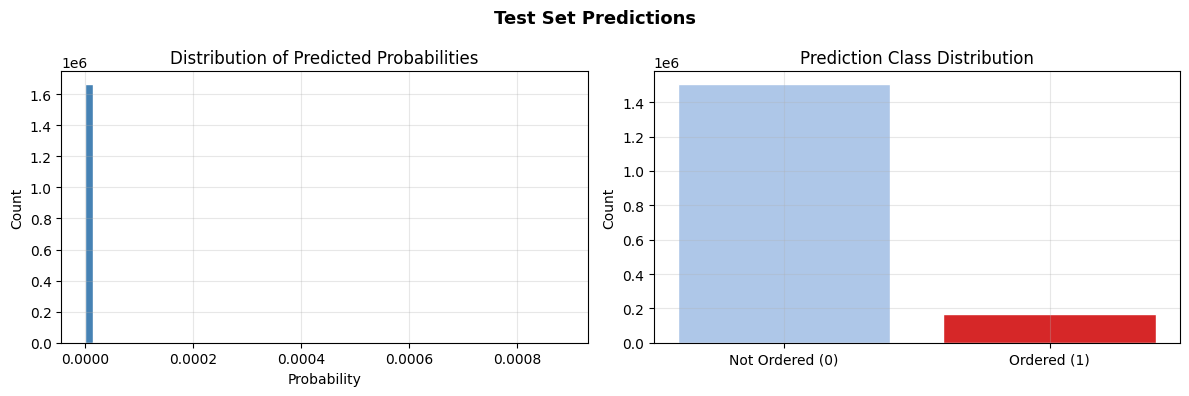

In [33]:
# Probability distribution on test set
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Test Set Predictions', fontsize=13, fontweight='bold')

axes[0].hist(test_df['prob'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Predicted Probabilities')
axes[0].set_xlabel('Probability'); axes[0].set_ylabel('Count')

axes[1].bar(['Not Ordered (0)','Ordered (1)'],
            [n_total-n_ones, n_ones],
            color=['#aec7e8','#d62728'], edgecolor='white')
axes[1].set_title('Prediction Class Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 💾 11. Save Submission

In [36]:
submission = test_df[['CID X LOC_NUM X VENDOR','target']].copy()
submission.to_csv('submission.csv', index=False)

print('submission.csv saved!')
print(f'Shape: {submission.shape}')
print('\nSample positive predictions:')
submission[submission['target']==1].head(10)

submission.csv saved!
Shape: (1672000, 2)

Sample positive predictions:


,CID X LOC_NUM X VENDOR,target
0,Z59FTQD X 0 X 4,1
15,Z59FTQD X 0 X 81,1
19,Z59FTQD X 0 X 85,1
28,Z59FTQD X 0 X 115,1
39,Z59FTQD X 0 X 180,1
49,Z59FTQD X 0 X 201,1
72,Z59FTQD X 0 X 310,1
82,Z59FTQD X 0 X 573,1
93,Z59FTQD X 0 X 845,1
96,Z59FTQD X 0 X 855,1


### Summary
- Framed as binary classification for ranking
- Used temporal split to avoid leakage
- Built geospatial, vendor, popularity, and interaction features
- Model: HistGradientBoostingClassifier
- Validation AUC: ~0.74 (realistic)